# Introduction to the Tropical Abel--Jacobi Transform

Yueqi Cao, *Department of Mathematics, Imperial College London*

## Metric Graphs

In [1]:
import sys
from pathlib import Path

src_path = Path("../src") 
sys.path.append(str(src_path))

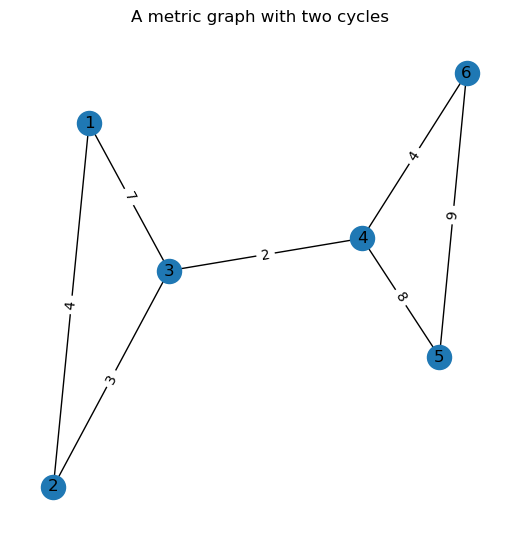

In [2]:
import mgraph
import networkx as nx
import matplotlib.pyplot as plt

# define a weighted graph with two cycles
MG = mgraph.MetricGraph()
# first cycle 
MG.add_edge(1, 2, weight = 4)
MG.add_edge(2, 3, weight = 3)
MG.add_edge(1, 3, weight = 7)
# bridge edge of the graph
MG.add_edge(3, 4, weight = 2) 
# second cycle
MG.add_edge(4, 5, weight = 8)
MG.add_edge(5, 6, weight = 9)
MG.add_edge(6, 4, weight = 4)

# draw the weighted graph
plt.figure(figsize=(5,5))
pos = nx.spring_layout(MG, seed=1)
nx.draw(MG, pos, with_labels=True)   
edge_labels = nx.get_edge_attributes(MG,'weight') 
edge_dic = nx.draw_networkx_edge_labels(MG, pos, edge_labels=edge_labels)
plt.title("A metric graph with two cycles")
plt.show()

The minimal spanning tree of MG is [(1, 2), (2, 3), (3, 4), (4, 6), (4, 5)]



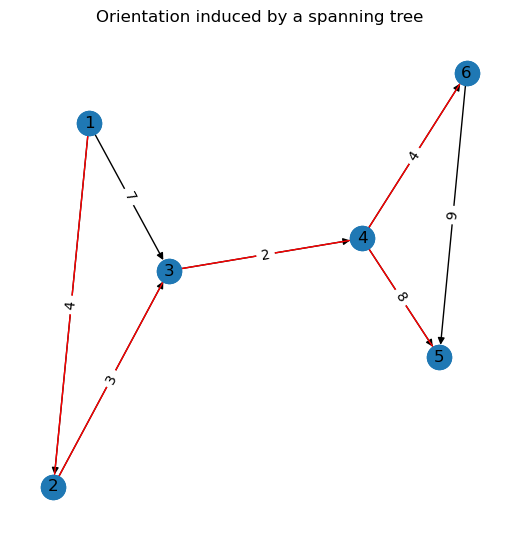

In [3]:
# compute the minimal spanning tree
MST = nx.minimum_spanning_tree(MG)
print("The minimal spanning tree of MG is {}\n".format(MST.edges()))

# orient the graph with respect to the tree MST
Directed_MG = MG.tree_orientation(MST)

# draw the weighted graph
plt.figure(figsize=(5,5))
nx.draw(Directed_MG, pos, with_labels=True)
nx.draw(MST, pos, edge_color="red")
edge_labels = nx.get_edge_attributes(MG,'weight') 
pic = nx.draw_networkx_edge_labels(MG, pos, edge_labels=edge_labels)
plt.title("Orientation induced by a spanning tree")
plt.show()

In [4]:
# compute the homology basis of MG with respect to MST
homology_basis =  MG.homology_basis(MST)

g = len(homology_basis)
print("the genus of the metric graph is", g)
for i in range(g):
    print("cycle {} is: {}".format(i, homology_basis[i].edges(data=True)))

the genus of the metric graph is 2
cycle 0 is: [(1, 3, {'weight': 7, 'sign': 1}), (1, 2, {'weight': 4, 'sign': -1}), (2, 3, {'weight': 3, 'sign': -1})]
cycle 1 is: [(6, 5, {'weight': 9, 'sign': 1}), (4, 6, {'weight': 4, 'sign': 1}), (4, 5, {'weight': 8, 'sign': -1})]


In [5]:
# compute the cycle-edge incidence matrix
C = MG.cycle_edge(MST)
print("the cycle-edge incidence matrix is\n", C)

C_st = MG.reduced_cycle_edge(MST)
print("the reduced cycle-edge incidence matrix is\n", C_st)

the cycle-edge incidence matrix is
 [[-1.  1. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  1. -1.  1.]]
the reduced cycle-edge incidence matrix is
 [[-1. -1.  0.  0.  0.]
 [ 0.  0.  0.  1. -1.]]


In [6]:
# compute the path-edge incidence matrix
base_point = list(MST.nodes())[1]

Y = MG.path_edge(MST, base_point)
print("the path-edge incidence matrix is \n", Y)

Y_st = MG.reduced_path_edge(MST, base_point)
print("the reduced path-edge incidence matrix is \n", Y_st)

the path-edge incidence matrix is 
 [[-1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.  0.  0.]
 [ 0.  0.  1.  1.  0.  0.  0.]
 [ 0.  0.  1.  1.  0.  1.  0.]
 [ 0.  0.  1.  1.  1.  0.  0.]]
the reduced path-edge incidence matrix is 
 [[-1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  1.  0.  0.  0.]
 [ 0.  1.  1.  0.  0.]
 [ 0.  1.  1.  0.  1.]
 [ 0.  1.  1.  1.  0.]]


In [ ]:
# compute the tropical Abel--Jacobi transform